### Ячейка 1: Импорты и Настройки

In [30]:
# Ячейка 1: Импорты и Настройки
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from perlin_noise import PerlinNoise # Убедитесь, что библиотека установлена: pip install perlin-noise
import ipywidgets as widgets
from ipywidgets import interact, fixed
from IPython.display import display, clear_output
import soundfile as sf # Для загрузки opus
from pathlib import Path
import warnings

# Подавление некоторых предупреждений librosa/matplotlib
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# --- Параметры ---
# Параметры аудио и STFT (можно взять из вашего основного конфига)
SR = 8000
N_FFT = 512
HOP_LENGTH = 96 # Важно использовать тот же hop_length, что и в модели

# Путь к ПРИМЕРУ аудиофайла (замените на реальный путь к одному из ваших .opus файлов)
# ВАЖНО: Укажите корректный путь!
SAMPLE_AUDIO_PATH = Path("./morse_dataset/morse_dataset/100.opus") # ЗАМЕНИТЕ ЭТО!

# Параметры Perlin Noise по умолчанию для виджетов
DEFAULT_OCTAVES = 4
DEFAULT_SEED = 42
DEFAULT_SCALE = 32.0 # Влияет на "масштаб" холмов/ям (больше -> крупнее)
DEFAULT_AMPLITUDE = 0.3 # Сила искажения (0.0 - нет искажений, 1.0 - очень сильные)

print("Библиотеки импортированы, параметры заданы.")
print(f"Пример аудио: {SAMPLE_AUDIO_PATH}")
if not SAMPLE_AUDIO_PATH.exists():
    print(f"!!! ВНИМАНИЕ: Файл {SAMPLE_AUDIO_PATH} не найден. Замените путь в коде!")

Библиотеки импортированы, параметры заданы.
Пример аудио: morse_dataset\morse_dataset\100.opus


### Ячейка 2: Загрузка Аудио и Генерация Базовой Спектрограммы

Output()

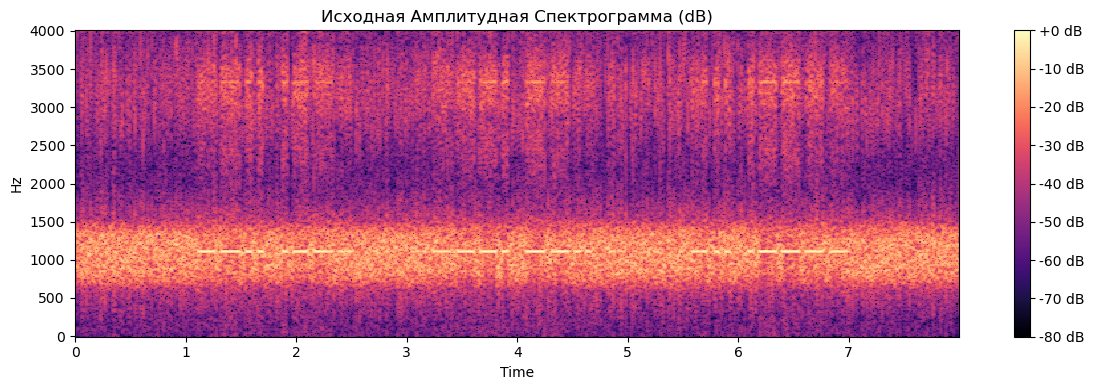

In [31]:
# Ячейка 2: Загрузка Аудио и Генерация Базовой Спектрограммы

original_spectrogram = None
audio_data = None
spec_shape = (0, 0) # (Частота, Время)

# Виджет для вывода состояния загрузки
load_output = widgets.Output()
display(load_output)

def load_and_process_audio(audio_path):
    """Загружает аудио и вычисляет линейную амплитудную спектрограмму."""
    global original_spectrogram, audio_data, spec_shape
    try:
        with load_output:
            clear_output(wait=True)
            print(f"Загрузка и обработка: {audio_path}...")
            if not audio_path.exists():
                print(f"❌ Ошибка: Файл не найден: {audio_path}")
                original_spectrogram = None
                audio_data = None
                spec_shape = (0,0)
                return False

            # Загрузка аудио с помощью soundfile (т.к. librosa может не поддерживать opus напрямую)
            audio_data, current_sr = sf.read(audio_path, dtype='float32')

            # Ресемплинг, если нужно
            if current_sr != SR:
                print(f"Ресемплинг из {current_sr} Hz в {SR} Hz...")
                audio_data = librosa.resample(y=audio_data, orig_sr=current_sr, target_sr=SR)

            # Вычисление STFT
            stft_result = librosa.stft(y=audio_data, n_fft=N_FFT, hop_length=HOP_LENGTH)
            original_spectrogram = np.abs(stft_result) # Берем амплитуду

            # Проверка на NaN/Inf
            if np.isnan(original_spectrogram).any() or np.isinf(original_spectrogram).any():
                print("❌ Ошибка: NaN/Inf в спектрограмме!")
                original_spectrogram = None
                spec_shape = (0,0)
                return False

            spec_shape = original_spectrogram.shape
            print(f"Спектрограмма успешно создана. Форма (F, T): {spec_shape}")
            print("Можно переходить к следующей ячейке.")
            return True

    except Exception as e:
        with load_output:
            clear_output(wait=True)
            print(f"❌ Ошибка при загрузке/обработке аудио: {e}")
        original_spectrogram = None
        audio_data = None
        spec_shape = (0,0)
        return False

# Запускаем загрузку
load_success = load_and_process_audio(SAMPLE_AUDIO_PATH)

# Отобразим исходную спектрограмму для проверки
if load_success and original_spectrogram is not None:
    plt.figure(figsize=(12, 4))
    # Используем amplitude_to_db для лучшей визуализации
    librosa.display.specshow(librosa.amplitude_to_db(original_spectrogram, ref=np.max),
                             sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='hz') # Используем 'hz' для оси Y
    plt.colorbar(format='%+2.0f dB')
    plt.title('Исходная Амплитудная Спектрограмма (dB)')
    plt.tight_layout()
    plt.show()
else:
    print("Не удалось загрузить или обработать аудио. Визуализация невозможна.")

### Ячейка 3: Функции для Генерации Шума и Визуализации

In [32]:
# Ячейка 3: Функции для Генерации Шума и Визуализации (v3 - С Аддитивным Смещением перед Перлином)
from typing import Optional, Tuple # <--- ДОБАВЛЕН Tuple ЗДЕСЬ
# Виджет для вывода результатов визуализации
plot_output = widgets.Output()

# --- Вспомогательная функция для генерации сырого шума Перлина [-1, 1] ---
def _generate_raw_perlin(shape: tuple, octaves: int, seed: int, scale: float) -> np.ndarray:
    """ Генерирует сырой шум Перлина, нормализованный примерно к [-1, 1]. """
    if not all(s > 0 for s in shape) or scale <= 0 or octaves < 1:
        print(f"Предупреждение: Некорректные параметры для _generate_raw_perlin: shape={shape}, octaves={octaves}, scale={scale}")
        return np.zeros(shape, dtype=np.float32)

    try:
        noise_gen = PerlinNoise(octaves=octaves, seed=seed)
        height, width = shape # F, T
        x_coords = np.arange(width) / scale
        y_coords = np.arange(height) / scale
        xv, yv = np.meshgrid(x_coords, y_coords)
        raw_noise = np.array([[noise_gen([xv[i, j], yv[i, j]]) for j in range(width)] for i in range(height)])

        max_abs_val = np.max(np.abs(raw_noise))
        if max_abs_val > 1e-6: norm_noise = raw_noise / max_abs_val
        else: norm_noise = raw_noise # Остается нулевым или близким к нулю
        return norm_noise.astype(np.float32)

    except Exception as e:
        print(f"Ошибка при генерации сырого шума Перлина: {e}")
        return np.zeros(shape, dtype=np.float32)

# --- Основная функция применения комбинированного шума ---
def apply_combined_noise(
    original_spec: np.ndarray,
    # Параметры мультипликативного шума Перлина
    multi_octaves: int, multi_seed: int, multi_scale: float, multi_amplitude: float,
    # Параметры хаоса (к мультипликативному шуму)
    chaos_amplitude: float, chaos_type: str,
    # Параметры аддитивного смещения (на основе Перлина)
    offset_octaves: int, offset_seed: int, offset_scale: float, max_offset_factor: float,
    # Параметры финального аддитивного Гауссова шума
    additive_gaussian_std: float
    ) -> Tuple[Optional[np.ndarray], Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Применяет шум:
    1. Вычисляет аддитивную карту смещения [0, max_offset] из Перлина.
    2. Вычисляет мультипликативную карту шума [~1-amp, ~1+amp] из Перлина (+ хаос).
    3. Применяет: (original_spec + offset_map) * multiplicative_map + additive_gaussian.
    Возвращает: (final_augmented_spec, offset_map, multiplicative_map)
    """
    if original_spec is None or original_spec.size == 0:
        print("Ошибка: Нет исходной спектрограммы для apply_combined_noise.")
        return None, None, None

    spec_shape = original_spec.shape # (F, T)

    # --- 1. Генерация Аддитивной Карты Смещения ---
    offset_map = np.zeros(spec_shape, dtype=np.float32)
    if max_offset_factor > 1e-6:
        # Вычисляем максимальное смещение
        avg_spec_val = np.mean(original_spec)
        max_offset = max_offset_factor * avg_spec_val

        # Генерируем сырой шум для смещения
        offset_raw_noise = _generate_raw_perlin(spec_shape, offset_octaves, offset_seed, offset_scale) # Диапазон ~[-1, 1]

        # Преобразуем в положительную карту смещения [0, max_offset]
        # (raw_noise + 1) / 2 -> [0, 1], затем умножаем на max_offset
        offset_map = (offset_raw_noise + 1.0) * 0.5 * max_offset
        offset_map = np.clip(offset_map, a_min=0.0, a_max=None) # Убедимся, что нет отрицательных

    # --- 2. Генерация Мультипликативной Карты Шума ---
    multi_raw_noise = _generate_raw_perlin(spec_shape, multi_octaves, multi_seed, multi_scale) # Диапазон ~[-1, 1]
    multiplicative_map = 1.0 + multi_amplitude * multi_raw_noise # Диапазон ~[1-amp, 1+amp]

    # Добавляем хаос к мультипликативной карте
    if chaos_amplitude > 1e-6:
        if chaos_type == 'uniform':
            random_chaos = np.random.uniform(-chaos_amplitude, chaos_amplitude, size=spec_shape)
        elif chaos_type == 'gaussian':
            random_chaos = np.random.normal(0.0, chaos_amplitude / 3.0, size=spec_shape)
        else: # По умолчанию uniform
            random_chaos = np.random.uniform(-chaos_amplitude, chaos_amplitude, size=spec_shape)
        multiplicative_map += random_chaos

    # Обрезаем мультипликативную карту снизу нулем
    multiplicative_map = np.clip(multiplicative_map, a_min=0.0, a_max=None)

    # --- 3. Применение шумов к спектрограмме ---
    # Шаг 3а: Добавляем смещение
    spec_with_offset = original_spec + offset_map
    spec_with_offset = np.clip(spec_with_offset, a_min=0.0, a_max=None) # На всякий случай

    # Шаг 3б: Применяем мультипликативный шум
    spec_after_multiplicative = spec_with_offset * multiplicative_map
    spec_after_multiplicative = np.clip(spec_after_multiplicative, a_min=0.0, a_max=None)

    # Шаг 3в: Добавляем финальный аддитивный Гауссов шум
    final_augmented_spec = spec_after_multiplicative
    if additive_gaussian_std > 1e-6:
        additive_noise = np.random.normal(0.0, additive_gaussian_std, size=spec_shape)
        final_augmented_spec = spec_after_multiplicative + additive_noise
        final_augmented_spec = np.clip(final_augmented_spec, a_min=0.0, a_max=None)

    return final_augmented_spec.astype(np.float32), offset_map.astype(np.float32), multiplicative_map.astype(np.float32)


# --- !!! ИЗМЕНЕНО: Функция отображения теперь показывает 3 карты/спектрограммы !!! ---
def plot_noise_maps_and_spectrogram(offset_map: np.ndarray, multiplicative_map: np.ndarray, augmented_spec: np.ndarray):
    """Отображает карту смещения, карту мультипликативного шума и аугментированную спектрограмму."""
    if offset_map is None or multiplicative_map is None or augmented_spec is None:
         print("Ошибка: Отсутствуют данные для отображения.")
         return

    with plot_output:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # 1. Карта Смещения (Аддитивная)
        ax = axes[0]
        img = ax.imshow(offset_map, aspect='auto', origin='lower', cmap='magma', interpolation='nearest')
        fig.colorbar(img, ax=ax, format='%.4f') # Более точный формат
        ax.set_title(f'Карта Смещения (Аддитивная)\nShape: {offset_map.shape}')
        ax.set_xlabel("Время (T)")
        ax.set_ylabel("Частота (F)")

        # 2. Карта Шума (Мультипликативная)
        ax = axes[1]
        vmin = max(0.0, 1.0 - np.percentile(np.abs(multiplicative_map - 1.0), 98) * 1.5)
        vmax = 1.0 + np.percentile(np.abs(multiplicative_map - 1.0), 98) * 1.5
        img = ax.imshow(multiplicative_map, aspect='auto', origin='lower', cmap='viridis', interpolation='nearest', vmin=vmin, vmax=vmax)
        fig.colorbar(img, ax=ax, format='%.2f')
        ax.set_title(f'Карта Шума (Мультипликативная)\nShape: {multiplicative_map.shape}')
        ax.set_xlabel("Время (T)")
        ax.set_ylabel("Частота (F)")

        # 3. Аугментированная спектрограмма (в dB)
        ax = axes[2]
        spec_db_aug = librosa.amplitude_to_db(augmented_spec + 1e-9, ref=np.max(augmented_spec + 1e-9)) # Используем max от аугментированной
        img = librosa.display.specshow(spec_db_aug, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='hz', ax=ax)
        fig.colorbar(img, ax=ax, format='%+2.0f dB')
        ax.set_title(f'Итоговая Спектрограмма (dB)\nShape: {augmented_spec.shape}')

        plt.tight_layout(pad=1.5)
        plt.show()

print("Функции генерации шума (v3 - с аддитивным смещением) и визуализации определены.")

Функции генерации шума (v3 - с аддитивным смещением) и визуализации определены.


### Ячейка 4: Интерактивная Визуализация

In [ ]:
# Ячейка 4: Интерактивная Визуализация (v3 - С Аддитивным Смещением перед Перлином)

# --- Функция interactive_perlin_visualization (переработана) ---
def interactive_perlin_visualization(
    # Параметры мультипликативного Перлина
    multi_octaves, multi_seed, multi_scale, multi_amplitude,
    # Параметры хаоса
    chaos_amplitude, chaos_type,
    # Параметры аддитивного смещения (Перлин)
    offset_octaves, offset_seed, offset_scale, max_offset_factor,
    # Параметры финального аддитивного Гаусса
    additive_gaussian_std
    ):
    """Функция, вызываемая виджетами для обновления визуализации."""
    if original_spectrogram is None:
        with plot_output:
            clear_output(wait=True)
            print("Ошибка: Исходная спектрограмма не загружена. Запустите Ячейку 2.")
        return

    # 1. Применяем все шумы с помощью новой функции
    final_augmented_spec, offset_map, multiplicative_map = apply_combined_noise(
        original_spec=original_spectrogram,
        multi_octaves=multi_octaves, multi_seed=multi_seed, multi_scale=multi_scale, multi_amplitude=multi_amplitude,
        chaos_amplitude=chaos_amplitude, chaos_type=chaos_type,
        offset_octaves=offset_octaves, offset_seed=offset_seed, offset_scale=offset_scale, max_offset_factor=max_offset_factor,
        additive_gaussian_std=additive_gaussian_std
    )

    # 2. Отображаем результаты
    plot_noise_maps_and_spectrogram(offset_map, multiplicative_map, final_augmented_spec)

# --- Создание интерактивных виджетов ---
style = {'description_width': 'initial'}

# --- Виджеты для Мультипликативного Перлина ---
multi_octaves_slider = widgets.IntSlider(min=1, max=10, step=1, value=DEFAULT_OCTAVES, description='Октавы (Множ.):', style=style, continuous_update=False)
multi_seed_slider = widgets.IntSlider(min=1, max=100, step=1, value=DEFAULT_SEED, description='Seed (Множ.):', style=style, continuous_update=False)
multi_scale_slider = widgets.FloatSlider(min=2.0, max=512.0, step=1.0, value=DEFAULT_SCALE, description='Масштаб (Множ.):', style=style, continuous_update=False, readout_format='.1f')
multi_amplitude_slider = widgets.FloatSlider(min=0.0, max=1.5, step=0.01, value=DEFAULT_AMPLITUDE, description='Амплитуда (Множ.):', style=style, continuous_update=False, readout_format='.2f')

# --- Виджеты для Хаоса (к мультипликативному) ---
chaos_amplitude_slider = widgets.FloatSlider(min=0.0, max=0.5, step=0.01, value=0.0, description='Ампл. Хаоса (к Множ.):', style=style, continuous_update=False, readout_format='.2f')
chaos_type_dropdown = widgets.Dropdown(options=['uniform', 'gaussian'], value='uniform', description='Тип Хаоса:', style=style)

# --- !!! ДОБАВЛЕНО: Виджеты для Аддитивного Смещения (Перлин) !!! ---
offset_octaves_slider = widgets.IntSlider(min=1, max=10, step=1, value=2, description='Октавы (Смещ.):', style=style, continuous_update=False) # Меньше октав по умолч.
offset_seed_slider = widgets.IntSlider(min=101, max=200, step=1, value=DEFAULT_SEED + 100, description='Seed (Смещ.):', style=style, continuous_update=False) # Другой диапазон сидов
offset_scale_slider = widgets.FloatSlider(min=2.0, max=128.0, step=1.0, value=16.0, description='Масштаб (Смещ.):', style=style, continuous_update=False, readout_format='.1f') # Меньший масштаб по умолч.
max_offset_factor_slider = widgets.FloatSlider(min=0.0, max=0.5, step=0.001, value=0.0, description='Макс. Смещ. (% от ср.):', style=style, continuous_update=False, readout_format='.3f') # До 5%
# -----------------------------------------------------------------

# --- Виджет для Финального Аддитивного Гаусса ---
additive_gaussian_slider = widgets.FloatSlider(min=0.0, max=0.5, step=0.001, value=0.0, description='Ст. откл. Аддитив. Гаусса:', style=style, continuous_update=False, readout_format='.3f')

# --- Связываем все виджеты с функцией визуализации ---
interaction = interact(
    interactive_perlin_visualization,
    # Мультипликативный Перлин
    multi_octaves=multi_octaves_slider,
    multi_seed=multi_seed_slider,
    multi_scale=multi_scale_slider,
    multi_amplitude=multi_amplitude_slider,
    # Хаос
    chaos_amplitude=chaos_amplitude_slider,
    chaos_type=chaos_type_dropdown,
    # Аддитивное Смещение
    offset_octaves=offset_octaves_slider,
    offset_seed=offset_seed_slider,
    offset_scale=offset_scale_slider,
    max_offset_factor=max_offset_factor_slider,
    # Финальный Гаусс
    additive_gaussian_std=additive_gaussian_slider
)

# Отображаем контейнер для графиков под виджетами
display(plot_output)

print("Интерактивные виджеты созданы (v3 - с аддитивным смещением).")
print("Теперь можно управлять параметрами обеих карт шума и финальным Гауссом.")

interactive(children=(IntSlider(value=4, continuous_update=False, description='Октавы (Множ.):', max=10, min=1…

Output()

Интерактивные виджеты созданы (v3 - с аддитивным смещением).
Теперь можно управлять параметрами обеих карт шума и финальным Гауссом.
